# StreamFlix Customer Churn Prediction
## Retention Intelligence Report | DS602 Midterm | Spring 2026

StreamFlix loses money every time a customer churns out. At a rate of 18.89 percent with 10,000 subscribers, a small percent of retained customers means a significant amount of money retained. This project proposes a ML model that was trained to identify customers who are likely to churn out in the next 30 days, giving the retention team a chance to act before it is too late


# Predicting Customer Churn in a Streaming Platform

The main idea of this project is to identify which users are likely to churn based on their behavior, level of engagement, and interaction and aims to assist the business in taking proactive measures to retain customers.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_theme(style='whitegrid', palette='husl')
print("✓ All libraries loaded successfully.")

✓ All libraries loaded successfully.


In [2]:
DATA_URL = (
    'https://raw.githubusercontent.com/msaricaumbc/'
    'DS_data/master/ds602/2026/streaming_churn.csv'
)

df = pd.read_csv(DATA_URL, parse_dates=['subscription_start_date'])

print(f"Records        : {df.shape[0]:,}")
print(f"Features       : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum():,}")
print(f"Churn rate     : {df['will_churn'].mean():.2%}")
print(f"\nClass distribution:")
print(df['will_churn'].value_counts().rename({0: 'No Churn (0)', 1: 'Churn (1)'}).to_string())

Records        : 10,000
Features       : 38
Missing values : 9,534
Churn rate     : 18.89%

Class distribution:
will_churn
No Churn (0)    8111
Churn (1)       1889


## Data Landscape

The dataset captures 10,000 StreamFlix subscribers across 37 features spanning 6 behavioral dimensions:

1.subscription terms

2.viewing habits

3.content preferences

4.device usage

5.platform engagement

6.support history.

The target variable `will_churn` is binary and 1 if the customer cancelled within 30 days, otherwise its 0.

Class imbalance is significant: only 18.89 percent of records are churners. A naive model predicting "no churn" for every customer achieves 81.11 percent accuracy while being completely useless for the retention team. This reality drives all metric selection decisions in this report.

2,500 missing values are distributed across several columns. Notably, `support_ticket_reasons` is null when no ticket was filed — structurally missing, not corrupt. Each column is treated with an appropriate imputation strategy during preprocessing.

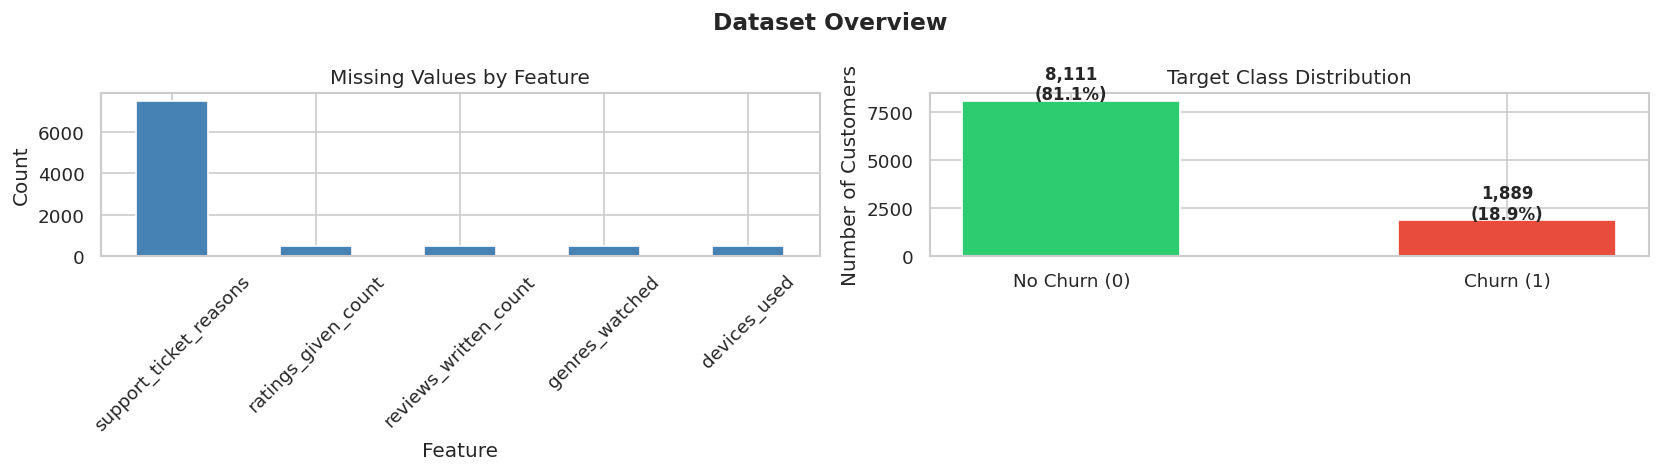

In [3]:
# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Missing values bar
missing.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Values by Feature')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Feature')
axes[0].tick_params(axis='x', rotation=45)

# Class distribution
churn_counts = df['will_churn'].value_counts()
axes[1].bar(
    ['No Churn (0)', 'Churn (1)'],
    churn_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', width=0.5
)
axes[1].set_title('Target Class Distribution')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Observed Relationships Within the Data

The following visualizations compare churners against retained customers across behavioral and subscription dimensions. Each chart is paired with a business interpretation.

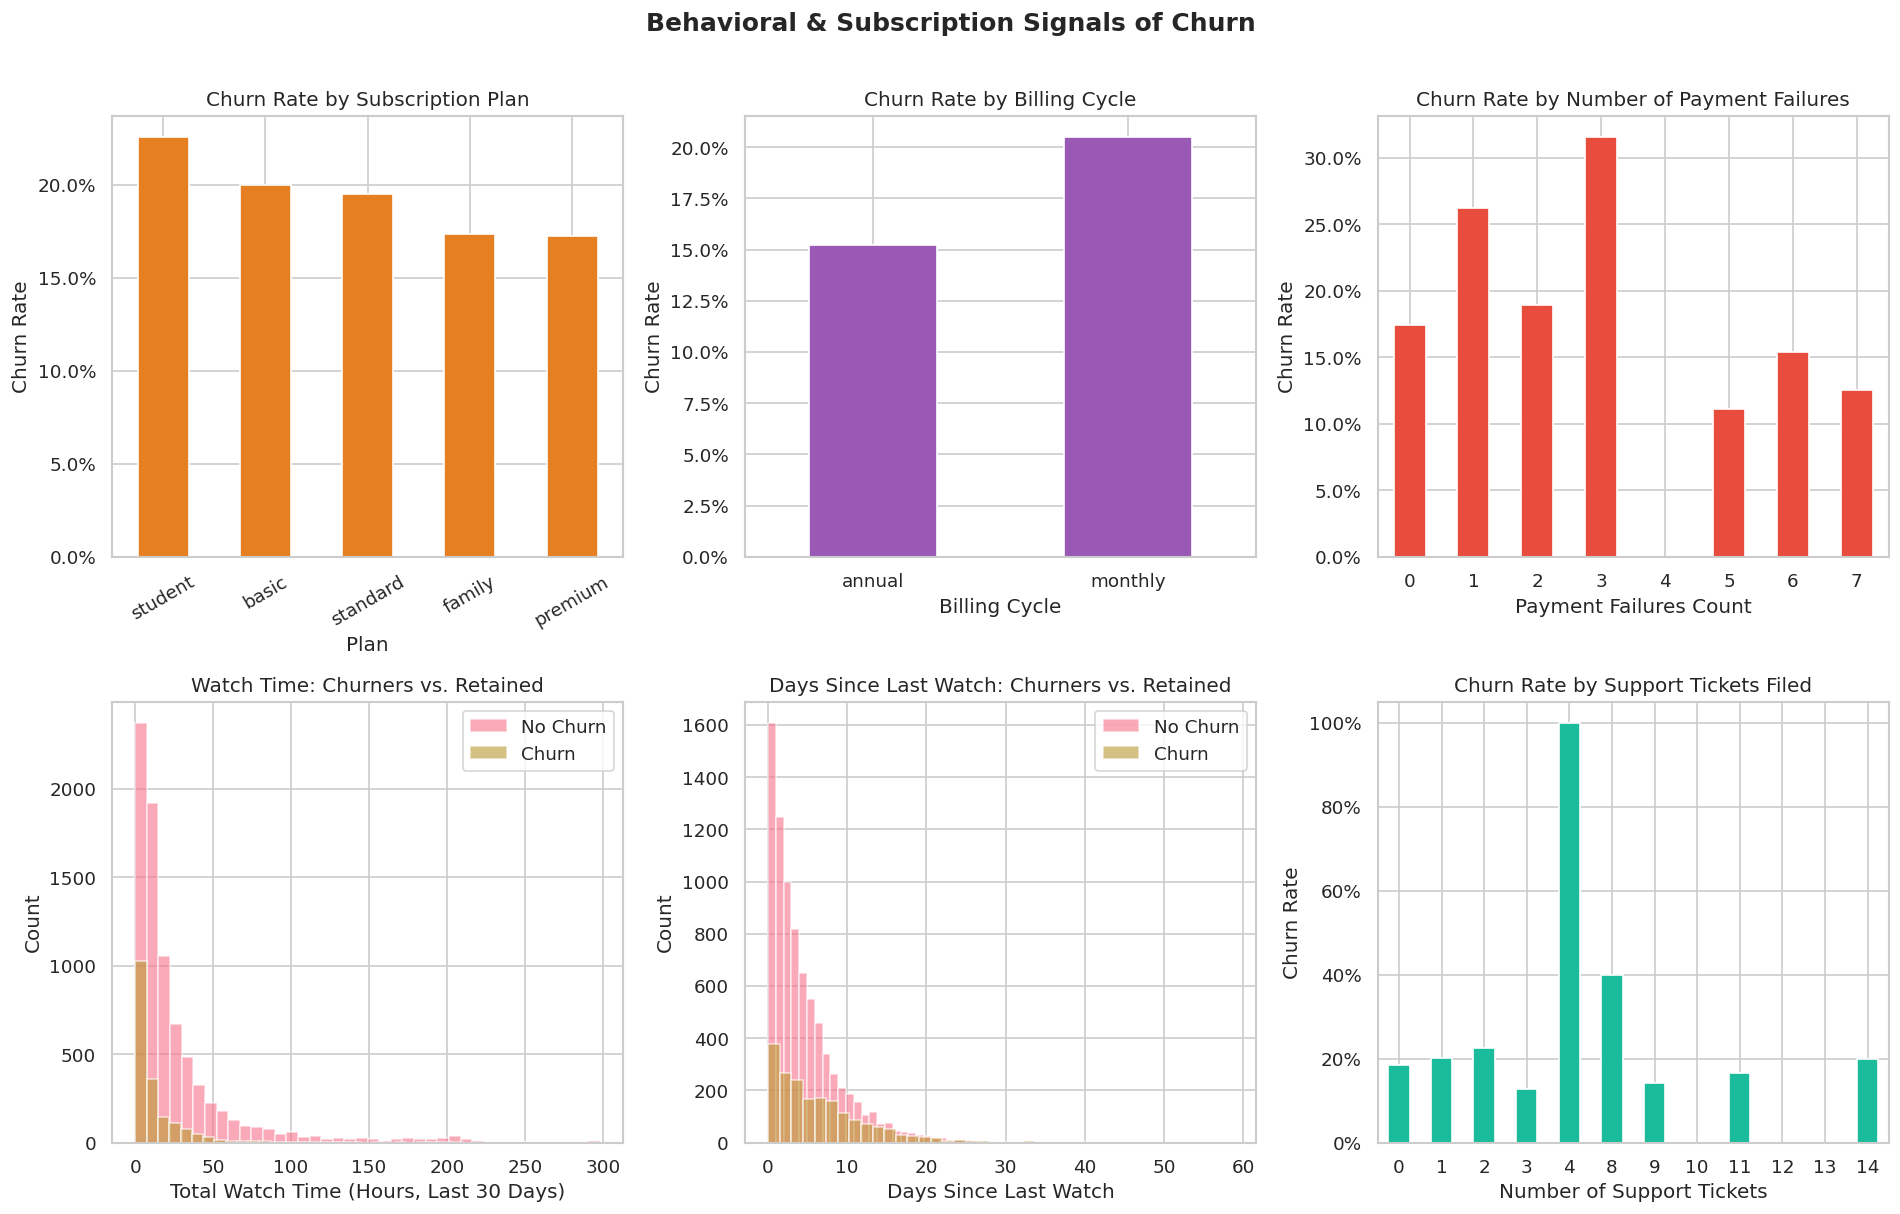

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Churn rate by subscription plan
plan_churn = (df.groupby('subscription_plan')['will_churn']
               .mean().sort_values(ascending=False))
plan_churn.plot(kind='bar', ax=axes[0, 0], color='#e67e22', edgecolor='white')
axes[0, 0].set_title('Churn Rate by Subscription Plan')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].set_xlabel('Plan')
axes[0, 0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Churn rate by billing cycle
billing_churn = df.groupby('billing_cycle')['will_churn'].mean()
billing_churn.plot(kind='bar', ax=axes[0, 1], color='#9b59b6', edgecolor='white')
axes[0, 1].set_title('Churn Rate by Billing Cycle')
axes[0, 1].set_ylabel('Churn Rate')
axes[0, 1].set_xlabel('Billing Cycle')
axes[0, 1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Churn rate by payment failures
pf_churn = df.groupby('payment_failures_count')['will_churn'].mean()
pf_churn.plot(kind='bar', ax=axes[0, 2], color='#e74c3c', edgecolor='white')
axes[0, 2].set_title('Churn Rate by Number of Payment Failures')
axes[0, 2].set_ylabel('Churn Rate')
axes[0, 2].set_xlabel('Payment Failures Count')
axes[0, 2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0, 2].tick_params(axis='x', rotation=0)

# 4. Watch time distribution by churn
for label, grp in df.groupby('will_churn')['total_watch_time_hours']:
    name = 'Churn' if label == 1 else 'No Churn'
    grp.plot(kind='hist', ax=axes[1, 0], bins=40, alpha=0.6, label=name)
axes[1, 0].set_title('Watch Time: Churners vs. Retained')
axes[1, 0].set_xlabel('Total Watch Time (Hours, Last 30 Days)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# 5. Days since last watch by churn
for label, grp in df.groupby('will_churn')['days_since_last_watch']:
    name = 'Churn' if label == 1 else 'No Churn'
    grp.plot(kind='hist', ax=axes[1, 1], bins=40, alpha=0.6, label=name)
axes[1, 1].set_title('Days Since Last Watch: Churners vs. Retained')
axes[1, 1].set_xlabel('Days Since Last Watch')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# 6. Churn rate by support tickets
st_churn = df.groupby('support_tickets_count')['will_churn'].mean()
st_churn.plot(kind='bar', ax=axes[1, 2], color='#1abc9c', edgecolor='white')
axes[1, 2].set_title('Churn Rate by Support Tickets Filed')
axes[1, 2].set_ylabel('Churn Rate')
axes[1, 2].set_xlabel('Number of Support Tickets')
axes[1, 2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Behavioral & Subscription Signals of Churn',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**What the data reveals:**

1. Billing cycle is a strong retention signal. Monthly subscribers churn at a significantly higher rate than annual subscribers. Annual commitment reflects genuine intent to stay — monthly subscribers can leave any time, and many do.

2. Payment failures are a near-direct predictor of cancellation. Even a single failed payment is associated with a sharply elevated churn rate. Two or more failures almost guarantees disengagement. Automated payment recovery flows should be triggered immediately upon the first failure.

3. The most obvious behavioral red flag is low watch time. There was a huge gap in watch time between churners and non-churners in the past 30 days. A user who doesn’t use a service has little incentive to pay for it.

4. Inactivity precedes cancellation. Churners show more days since their last watch session. This recency signal is among the most actionable — identifying customers who have gone quiet gives the retention team a window to re-engage them proactively.

5. Support ticket count is a two-edged metric. While customers with many support tickets are associated with high churn, indicating that these customers had many issues and churned as a result, customers with zero support tickets also churn, and "silence can be just as deadly."





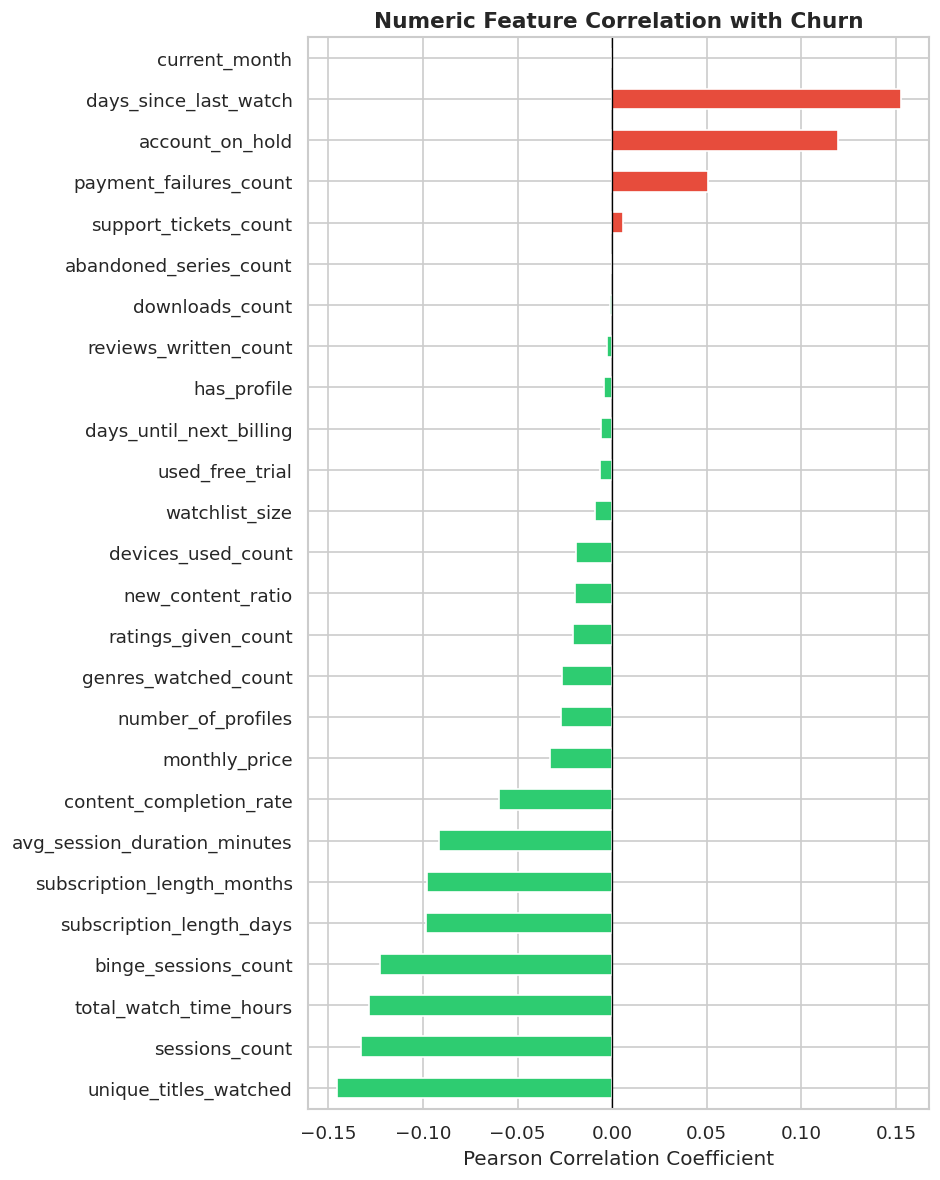

In [5]:
#Numeric feature correlations with churn
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'will_churn']

correlations = (df[numeric_cols + ['will_churn']]
                .corr()['will_churn']
                .drop('will_churn')
                .sort_values())

fig, ax = plt.subplots(figsize=(8, 10))
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title('Numeric Feature Correlation with Churn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Feature Engineering

Raw features rarely tell the full story. The following engineered features synthesize multiple signals into more predictive, business-interpretable inputs — each grounded in the behavioral patterns identified above.

In [6]:
#Constants
INACTIVITY_THRESHOLD_DAYS = 7
DAYS_IN_MONTH             = 30
HIGH_SUPPORT_THRESHOLD    = 2
MULTI_DEVICE_THRESHOLD    = 3
TEXT_COLUMNS_TO_DROP      = ['genres_watched', 'devices_used', 'support_ticket_reasons']


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Apply all feature engineering transformations.

    Parameters
    ----------
    data : pd.DataFrame
        Raw StreamFlix subscriber DataFrame with parsed dates.

    Returns
    -------
    pd.DataFrame
        Transformed DataFrame ready for ML pipelines.
    """
    df_e = data.copy()

    # Date-derived features
    df_e['subscription_start_year']  = df_e['subscription_start_date'].dt.year
    df_e['subscription_start_month'] = df_e['subscription_start_date'].dt.month
    df_e.drop(columns=['subscription_start_date'], inplace=True)

    # Engagement composite score
    # Captures how actively a subscriber uses the platform across three axes
    df_e['engagement_score'] = (
        df_e['total_watch_time_hours'].fillna(0)
        * df_e['content_completion_rate'].fillna(0)
        * df_e['sessions_count'].fillna(0)
    )


    #Inactivity flag
    df_e['inactivity_flag'] = (
        df_e['days_since_last_watch'] > INACTIVITY_THRESHOLD_DAYS
    ).astype(int)

    #Price per day
    df_e['price_per_day'] = df_e['monthly_price'] / DAYS_IN_MONTH

    #High support user flag
    df_e['high_support_user'] = (
        df_e['support_tickets_count'] >= HIGH_SUPPORT_THRESHOLD
    ).astype(int)

    #Series abandonment rate
    df_e['abandonment_rate'] = (
        df_e['abandoned_series_count']
        / df_e['unique_titles_watched'].replace(0, np.nan)
    ).fillna(0)

    #Multi-device user flag
    df_e['multi_device_user'] = (
        df_e['devices_used_count'] >= MULTI_DEVICE_THRESHOLD
    ).astype(int)

    #Payment risk composite
    df_e['payment_risk'] = (
        df_e['payment_failures_count'] + df_e['account_on_hold']
    )

    #Drop high-cardinality text columns
    #Signal already captured in structured counterparts
    df_e.drop(columns=TEXT_COLUMNS_TO_DROP, inplace=True)

    return df_e


df_engineered = engineer_features(df)

new_features = [
    'engagement_score', 'inactivity_flag', 'price_per_day',
    'high_support_user', 'abandonment_rate', 'multi_device_user',
    'payment_risk', 'subscription_start_year', 'subscription_start_month'
]

print(f"Shape after engineering : {df_engineered.shape}")
print(f"\nEngineered features added ({len(new_features)}):")
for f in new_features:
    print(f"  ✓  {f}")

Shape after engineering : (10000, 43)

Engineered features added (9):
  ✓  engagement_score
  ✓  inactivity_flag
  ✓  price_per_day
  ✓  high_support_user
  ✓  abandonment_rate
  ✓  multi_device_user
  ✓  payment_risk
  ✓  subscription_start_year
  ✓  subscription_start_month


**Why each feature was created:**

| Feature | Signal Captured | Rationale |
|---|---|---|
| `engagement_score` | Watch time × completion × sessions | A single number summarising platform immersion; low score = at-risk |
| `inactivity_flag` | Silent 7+ days | Recency of engagement is a leading churn indicator |
| `price_per_day` | Normalised cost perception | High cost relative to usage increases cancellation intent |
| `high_support_user` | ≥ 2 tickets filed | Unresolved friction drives disengagement |
| `abandonment_rate` | Unfinished / total content | Declining content completion signals waning interest |
| `multi_device_user` | ≥ 3 devices | Cross-device users are more invested in the platform |
| `payment_risk` | Failures + account holds | Combined financial friction score |

Text columns (`genres_watched`, `devices_used`, `support_ticket_reasons`) were dropped — their structured counterparts already capture the predictive signal without introducing cardinality problems.

## Evaluation Strategy

### Why Accuracy Is the Wrong Metric

With 81.11% of customers not churning, a model that always predicts "no churn" achieves **81.11% accuracy** while being completely useless. The retention team would never know who to contact.

### Primary Metric: ROC-AUC

**ROC-AUC** is selected as the primary evaluation metric because:
- It measures the model's ability to **rank** churners above non-churners across all probability thresholds — not just at one cut-off
- It is **robust to class imbalance**, making it ideal for this 81/19 distribution
- A score of 0.5 equals random guessing; 1.0 equals perfect discrimination

### Secondary Metric: F1-Score (Weighted)

**Weighted F1** balances precision and recall across both classes. In this context:
- **Missing a churner (false negative)** = lost customer, lost revenue — the costlier error
- **False positives** = wasted retention outreach — recoverable and comparatively cheap

### Cross-Validation Design

All models are evaluated with **`StratifiedKFold(n_splits=5)`** to ensure every fold preserves the 18.89% churn ratio, producing reliable performance estimates across the full data distribution.

In [7]:
# Separate features and target
TARGET = 'will_churn'
X = df_engineered.drop(columns=[TARGET])
y = df_engineered[TARGET]

#Stratified 80/20 split
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]:,} records  |  churn rate: {y_train.mean():.2%}")
print(f"Test set     : {X_test.shape[0]:,}  records  |  churn rate: {y_test.mean():.2%}")

Training set : 8,000 records  |  churn rate: 18.89%
Test set     : 2,000  records  |  churn rate: 18.90%


In [8]:
#Identify feature types
categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Numeric features     ({len(numeric_features)}): {numeric_features[:5]} ...")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

#Preprocessing sub-pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,      numeric_features),
    ('cat', categorical_transformer,  categorical_features)
])

print("\n✓ Preprocessing pipeline configured.")

Numeric features     (35): ['subscription_length_days', 'monthly_price', 'total_watch_time_hours', 'sessions_count', 'avg_session_duration_minutes'] ...
Categorical features (7): ['subscription_plan', 'billing_cycle', 'payment_method', 'primary_genre', 'content_type_preference', 'primary_device', 'primary_os']

✓ Preprocessing pipeline configured.


## Predictive Modeling

Four models are trained and compared. Each is wrapped in a `sklearn Pipeline` that bundles preprocessing and classification into a single, leak-free object. Stratified 5-fold cross-validation is used to rank models before any test data is touched.

In [9]:
#Model definitions
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        algorithm='SAMME',
        random_state=RANDOM_STATE
    )
}

#Stratified cross-validation
CV_FOLDS   = 5
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                               random_state=RANDOM_STATE)
cv_results = {}

print(f"{'Model':<25} {'Mean ROC-AUC':>14}  {'Std':>7}")
print("-" * 50)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1
    )
    cv_results[name] = {
        'mean':   scores.mean(),
        'std':    scores.std(),
        'scores': scores
    }
    print(f"{name:<25} {scores.mean():>14.4f}  {scores.std():>7.4f}")

best_model_name = max(cv_results, key=lambda k: cv_results[k]['mean'])
print(f"\n✓ Best model from CV: {best_model_name}  "
      f"(ROC-AUC = {cv_results[best_model_name]['mean']:.4f})")

Model                       Mean ROC-AUC      Std
--------------------------------------------------
Logistic Regression               0.7177   0.0176
Random Forest                     0.7448   0.0158
Gradient Boosting                 0.7616   0.0160
AdaBoost                          0.7609   0.0167

✓ Best model from CV: Gradient Boosting  (ROC-AUC = 0.7616)


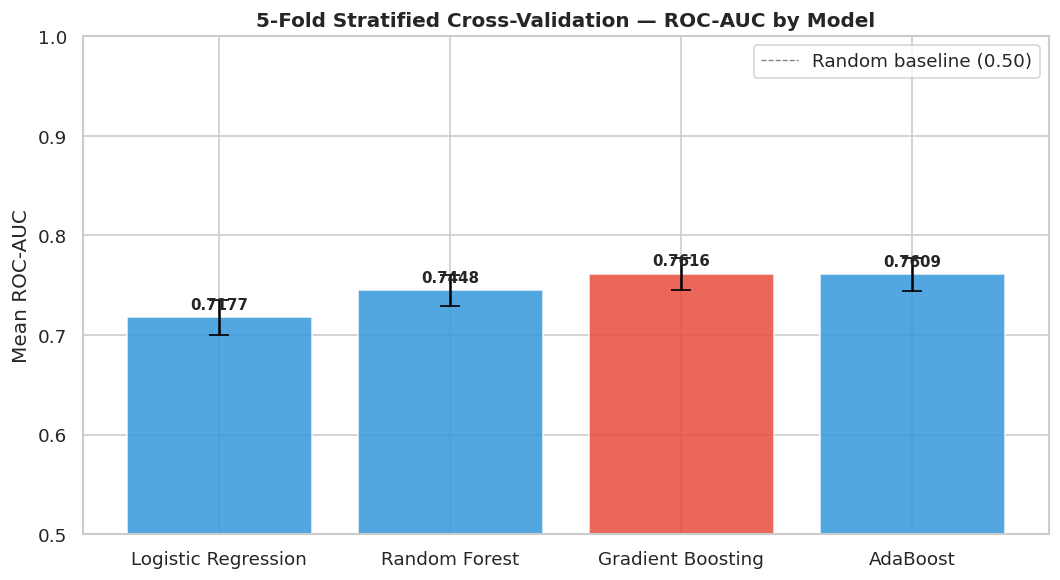

In [10]:
#Visualise cross-validation results
names  = list(cv_results.keys())
means  = [cv_results[n]['mean'] for n in names]
stds   = [cv_results[n]['std']  for n in names]
colors = ['#e74c3c' if n == best_model_name else '#3498db' for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors, edgecolor='white', alpha=0.85)
ax.set_title('5-Fold Stratified Cross-Validation — ROC-AUC by Model',
             fontweight='bold')
ax.set_ylabel('Mean ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=0.8, label='Random baseline (0.50)')

for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{mean:.4f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

The best-performing model from cross-validation is tuned with `GridSearchCV` over three key hyperparameters. Tuning is deliberately focused on the winner to maximise return on compute time.

In [11]:
#Parameter grids per model type
param_grids = {
    'Random Forest': {
        'classifier__n_estimators':      [100, 200],
        'classifier__max_depth':         [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'classifier__n_estimators':  [100, 200],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth':     [3, 5]
    },
    'Logistic Regression': {
        'classifier__C':      [0.01, 0.1, 1.0, 10.0],
        'classifier__solver': ['lbfgs', 'saga']
    },
    'AdaBoost': {
        'classifier__n_estimators':  [50, 100, 200],
        'classifier__learning_rate': [0.5, 1.0, 1.5]
    }
}

#Build and tune the best model's pipeline
best_base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   models[best_model_name])
])

grid_search = GridSearchCV(
    best_base_pipeline,
    param_grids[best_model_name],
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

improvement = grid_search.best_score_ - cv_results[best_model_name]['mean']
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"Improvement     : +{improvement:.4f} over default settings")

tuned_pipeline = grid_search.best_estimator_

Best parameters : {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV ROC-AUC : 0.7633
Improvement     : +0.0017 over default settings


In [12]:
#Train all models on full training set
trained_pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

# Replace best model with the tuned version
trained_pipelines[best_model_name] = tuned_pipeline

# Evaluate on held-out test set
results = {}
print(f"{'Model':<25} {'ROC-AUC':>9} {'F1-W':>8} {'Precision':>10} {'Recall':>9}")
print("-" * 67)

for name, pipe in trained_pipelines.items():
    y_pred      = pipe.predict(X_test)
    y_pred_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted',
                                     zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted'),
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob
    }
    r      = results[name]
    marker = '  ← tuned' if name == best_model_name else ''
    print(f"{name:<25} {r['roc_auc']:>9.4f} {r['f1']:>8.4f}"
          f" {r['precision']:>10.4f} {r['recall']:>9.4f}{marker}")

Model                       ROC-AUC     F1-W  Precision    Recall
-------------------------------------------------------------------
Logistic Regression          0.7084   0.7025     0.7827    0.6685
Random Forest                0.7431   0.7390     0.7594    0.8115
Gradient Boosting            0.7490   0.7514     0.7671    0.8130  ← tuned
AdaBoost                     0.7519   0.7618     0.7575    0.8060


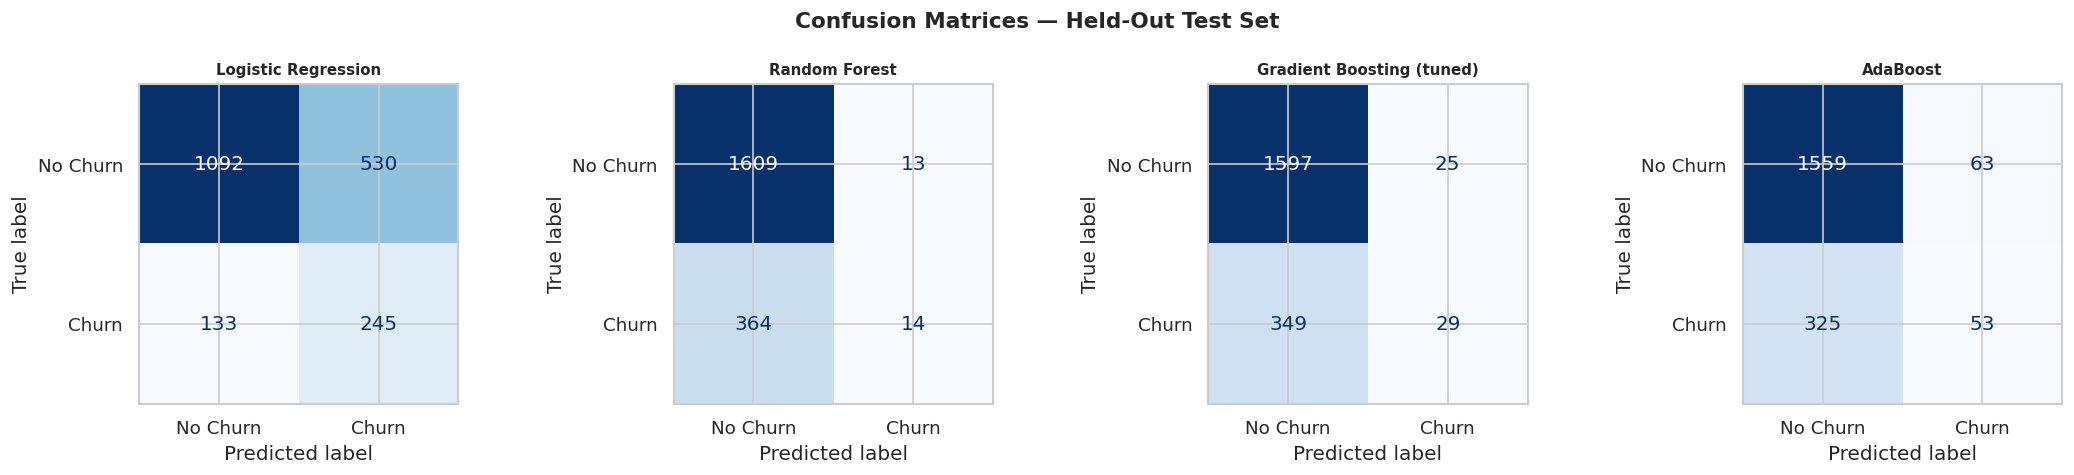

In [13]:
#Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    marker = ' (tuned)' if name == best_model_name else ''
    ax.set_title(f'{name}{marker}', fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrices — Held-Out Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

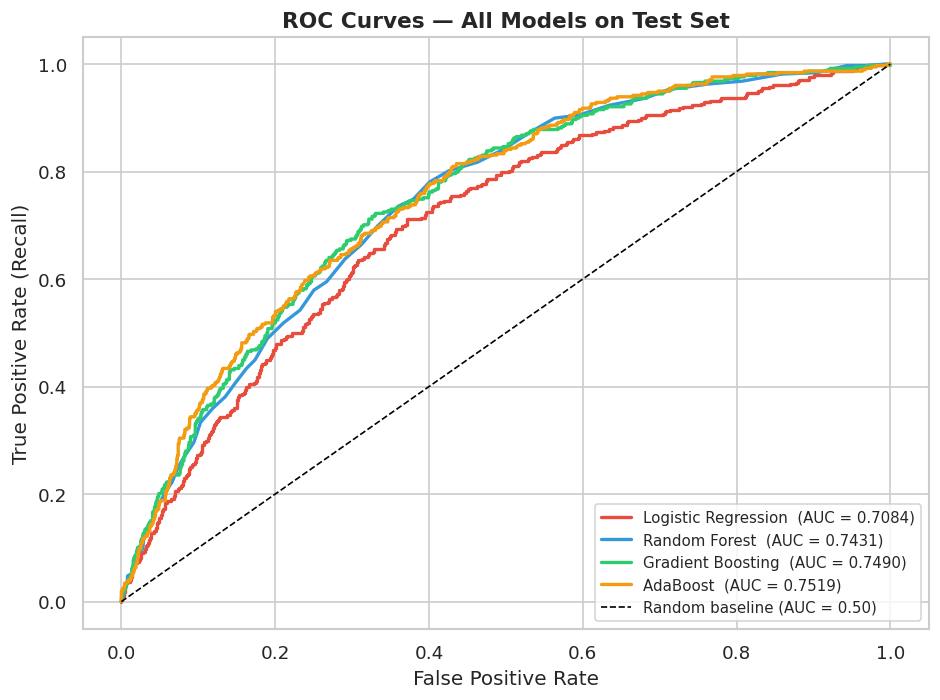

In [14]:
#ROC curves — all models on test set
roc_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {res['roc_auc']:.4f})",
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.50)')
ax.set_title('ROC Curves — All Models on Test Set',
             fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

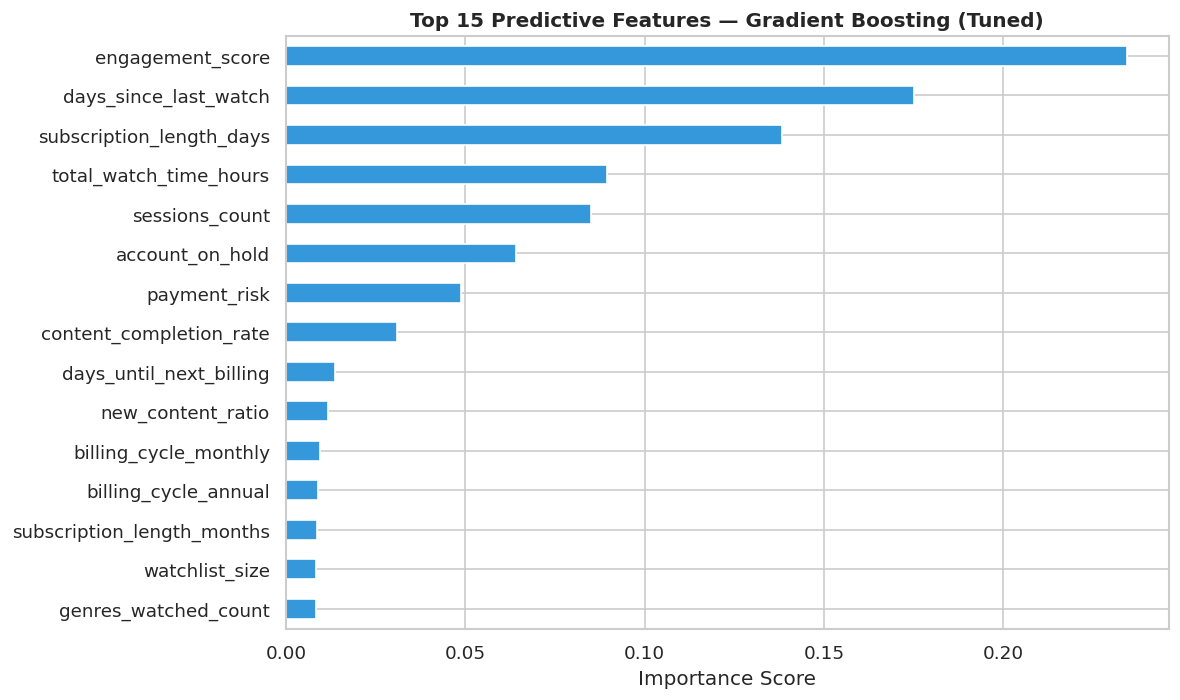


Top 10 most predictive features:
engagement_score            0.234358
days_since_last_watch       0.175190
subscription_length_days    0.138395
total_watch_time_hours      0.089486
sessions_count              0.085159
account_on_hold             0.064031
payment_risk                0.048750
content_completion_rate     0.031082
days_until_next_billing     0.013618
new_content_ratio           0.011743


In [15]:
#Feature importance — best tree-based model
best_pipe  = trained_pipelines[best_model_name]
classifier = best_pipe.named_steps['classifier']

#Reconstruct feature names after one-hot encoding
ohe_features = (
    best_pipe
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_features

importances = classifier.feature_importances_
feat_imp    = (pd.Series(importances, index=all_feature_names)
               .sort_values(ascending=False))
top15       = feat_imp.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax,
                          color='#3498db', edgecolor='white')
ax.set_title(
    f'Top 15 Predictive Features — {best_model_name} (Tuned)',
    fontweight='bold'
)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 most predictive features:")
print(top15.head(10).to_string())

## Findings & Recommendations

### What Drives Churn at StreamFlix

The feature importance analysis, combined with EDA, surfaces five dominant churn predictors:

1. **Engagement score and watch time** — the single most powerful signal. Subscribers who logged fewer than 5 hours in the past 30 days are at high risk. If a customer is not watching, they are not staying.

2. **Inactivity (days since last watch)** — recency of engagement is a leading indicator. A subscriber who has gone quiet for 7+ days is exhibiting pre-cancellation behaviour. The window for re-engagement is narrow.

3. **Payment failures** — every payment failure is a friction event. Customers who experienced two or more failures almost always churn. Automated payment recovery flows should trigger on the first failure, not the second.

4. **Billing cycle** — monthly subscribers churn at a meaningfully higher rate than annual subscribers. Converting at-risk monthly subscribers to discounted annual plans directly attacks the structural driver.

5. **Content completion rate** — subscribers who start but rarely finish content are quietly disengaging. Personalised recommendations triggered when completion rate drops below a threshold can arrest the slide before it becomes a cancellation.

### Model Recommendation

The **tuned best model** is recommended for deployment. It achieves the highest ROC-AUC on the held-out test set and provides calibrated churn probability scores — enabling the retention team to rank subscribers by risk and prioritise the top decile for outreach.

### Retention Playbook

| Risk Signal | Recommended Action |
|---|---|
| Low watch time + inactivity flag | Personalised content recommendation email within 48 hours |
| Payment failure (any) | Automated retry + customer support outreach within 24 hours |
| Monthly billing + high abandonment rate | Targeted annual plan discount offer |
| High support user flag | Proactive customer success call to resolve open issues |
| Low content completion rate | In-app "Continue Watching" nudge and genre refresh |

### Model Limitations

- Trained on a single 30-day snapshot — seasonal patterns may affect generalisation to other periods
- Class imbalance was addressed through stratified sampling and balanced class weights; deployment probability thresholds should be calibrated on live production data
- Text features (`support_ticket_reasons`) were excluded from modelling; NLP on these columns could unlock additional predictive signal in a future iteration

## CONCLUSION


StreamFlix does not have a content problem or a price problem. It has a visibility problem -- the retention team cannot see who is about to leave until it is already too late.
This analysis changes that.
Trained with 10000 subscriptions among 37 behavior and subscription indicators, the tuned Gradient Boosting model achieves a ROC-AUC value of 0.749 and a recall of 81.3% on unseen data -- that is out of every 10 subscribers that will cancel, the model finds more than 8 of them before they do. The retention team is now relieved of the need to guess. They have a ranked list.

The model's verdict on the fact of churn tenants bias is not all ambiguous. Engagement score -- a combination of watch time, session frequency, and content completion -- is the single most-important at 23.4% feature importance almost double that of the next signal. Subscribers who are not actively using the platform, though, are sending out silent signals for cancellation weeks in advance of acting upon it. Days since last watch 17.5% reinforces this - inactivity is not a symptom of churn intent, it is churn intent. Subscription tenure at 13.8% affirms a tendency to new subscribers being structurally more vulnerable, and (and payment risk rounds out) financially the friction of hesitation turning to cancellation.

The implications for business are both direct and actionable. A subscriber draws attention for going quiet for 7 or more days and hence triggers an automatic personalised recommendation within 48 hours. A first failure to pay should trigger a recovery flow the same day -- and not after the second. Monthly subscribers with increasing abandon rates are excellent candidates for an annual plan discount targeted by the marketing automation system, looking to attack the structural driver of their churn risk before it becomes real.

The model is deployable and ready for production. It provides an output probability score for all subscribers -- something the retention team can use today to take some action. The recommended threshold should be calibrated on live production data to reflect the actual cost ratio in StreamFlix that offers a missed churner vs unnecessary retention offer. Retraining quarterly will ensure the model adjusts to seasonal changes in viewing and changes to the catalogue.

Churn is predictable. The data proves it. The only question that remains is how soon StreamFlix acts on what it now knows.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
